## 1. Load Everything

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import torch
from transformers import AutoTokenizer

from config import MODEL_NAME, MAX_LEN, NUM_SENTIMENTS, NUM_ASPECTS, MODEL_SAVE_PATH, SENTIMENT_MAP_PATH, ASPECT_MAP_PATH
from utils import get_path, load_pickle
from model import PhoBERTABSA

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [2]:
test_df = pd.read_csv(get_path("data", "processed", "test_encoded.csv"))
test_enc = torch.load(get_path("data", "processed", "test_enc.pt"), weights_only=False)
sentiment_map = load_pickle(get_path(SENTIMENT_MAP_PATH))
aspect_map = load_pickle(get_path(ASPECT_MAP_PATH))

print("Test set:", test_df.shape)
test_df.head()

Test set: (3041, 3)


,review,aspect,sentiment
0,kimchi kimchi nói cho cùng thì đồ ăn càng cay ...,4,2
1,kimchi kimchi nói cho cùng thì đồ ăn càng cay ...,5,2
2,kimchi kimchi nói cho cùng thì đồ ăn càng cay ...,6,2
3,ở quảng tên mấy tiệm mì quảng thường đặt tên t...,0,2
4,ở quảng tên mấy tiệm mì quảng thường đặt tên t...,5,2


In [3]:
model = PhoBERTABSA(MODEL_NAME, NUM_SENTIMENTS, NUM_ASPECTS)
model.load_state_dict(torch.load(get_path(MODEL_SAVE_PATH), map_location=device, weights_only=False))
model.to(device)
model.eval()
print("Model loaded")

c:\Users\thevi\Documents\Code\viet-restaurant-absa\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded


## 2. Run Predictions on Test

In [4]:
from torch.utils.data import DataLoader, TensorDataset

input_ids = test_enc['input_ids']
attention_mask = test_enc['attention_mask']

dataset = TensorDataset(input_ids, attention_mask)
loader = DataLoader(dataset, batch_size=32)

all_sentiment_preds = []
all_aspect_preds = []

with torch.no_grad():
    for input_ids_batch, attention_mask_batch in loader:
        input_ids_batch = input_ids_batch.to(device)
        attention_mask_batch = attention_mask_batch.to(device)

        sentiment_logits, aspect_logits = model(input_ids_batch, attention_mask_batch)
        all_sentiment_preds.extend(sentiment_logits.argmax(dim=1).cpu().tolist())
        all_aspect_preds.extend(aspect_logits.argmax(dim=1).cpu().tolist())

test_df['pred_sentiment'] = all_sentiment_preds
test_df['pred_aspect'] = all_aspect_preds
print("Predictions done")

Predictions done


## 3. Overall Accuracy

In [5]:
sentiment_acc = (test_df['sentiment'] == test_df['pred_sentiment']).mean()
aspect_acc = (test_df['aspect'] == test_df['pred_aspect']).mean()

print(f"Sentiment Accuracy: {sentiment_acc:.4f}")
print(f"Aspect Accuracy   : {aspect_acc:.4f}")

Sentiment Accuracy: 0.7616
Aspect Accuracy   : 0.2914


## 4. Classification Report

In [6]:
from sklearn.metrics import classification_report

inv_sentiment = {v: k for k, v in sentiment_map.items()}
inv_aspect = {v: k for k, v in aspect_map.items()}

print("=== Sentiment ===")
print(classification_report(
    test_df['sentiment'],
    test_df['pred_sentiment'],
    target_names=[inv_sentiment[i] for i in range(NUM_SENTIMENTS)]
))

=== Sentiment ===
              precision    recall  f1-score   support

    positive       0.50      0.22      0.31       557
     neutral       0.55      0.32      0.40       241
    negative       0.80      0.94      0.86      2243

    accuracy                           0.76      3041
   macro avg       0.62      0.49      0.53      3041
weighted avg       0.72      0.76      0.73      3041



In [7]:
print("=== Aspect ===")
print(classification_report(
    test_df['aspect'],
    test_df['pred_aspect'],
    target_names=[inv_aspect[i] for i in range(NUM_ASPECTS)]
))

=== Aspect ===
                          precision    recall  f1-score   support

        AMBIENCE#GENERAL       0.21      0.29      0.25       237
           DRINKS#PRICES       0.00      0.00      0.00        41
          DRINKS#QUALITY       0.00      0.00      0.00        46
    DRINKS#STYLE&OPTIONS       0.00      0.00      0.00        31
             FOOD#PRICES       0.30      0.31      0.31       496
            FOOD#QUALITY       0.35      0.56      0.43       850
      FOOD#STYLE&OPTIONS       0.25      0.09      0.14       542
        LOCATION#GENERAL       0.21      0.22      0.22       125
      RESTAURANT#GENERAL       0.20      0.03      0.05       262
RESTAURANT#MISCELLANEOUS       0.25      0.01      0.02        82
       RESTAURANT#PRICES       0.00      0.00      0.00        66
         SERVICE#GENERAL       0.21      0.38      0.27       263

                accuracy                           0.29      3041
               macro avg       0.17      0.16      0.14    

c:\Users\thevi\Documents\Code\viet-restaurant-absa\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thevi\Documents\Code\viet-restaurant-absa\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thevi\Documents\Code\viet-restaurant-absa\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

## 5. Confusion Matrix

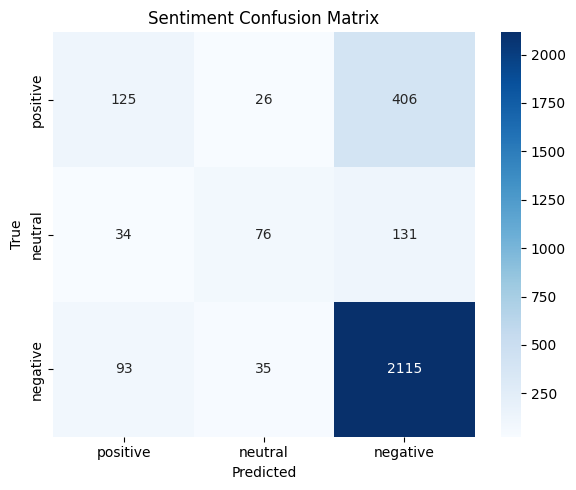

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_df['sentiment'], test_df['pred_sentiment'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=inv_sentiment.values(),
            yticklabels=inv_sentiment.values())
plt.title('Sentiment Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

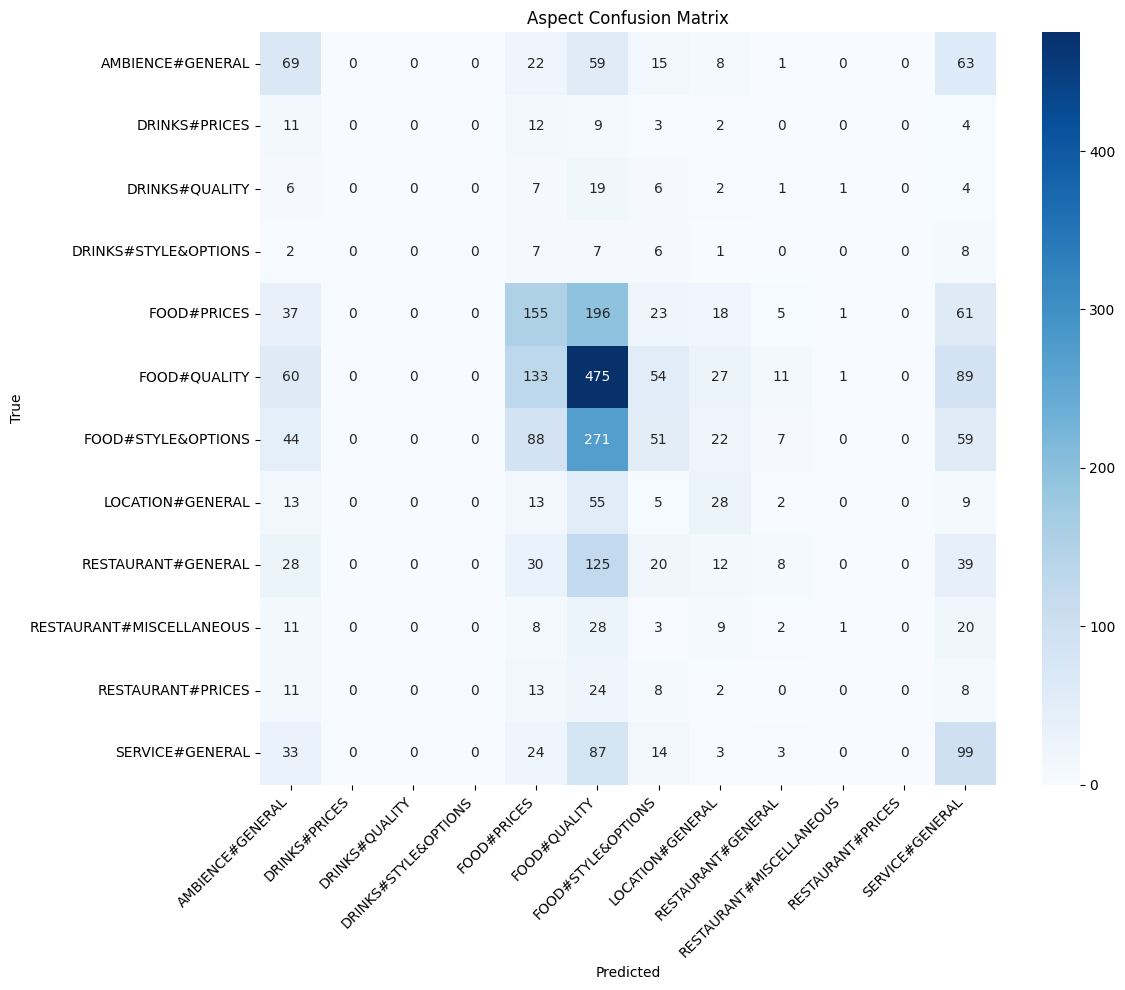

In [9]:
cm_aspect = confusion_matrix(test_df['aspect'], test_df['pred_aspect'])
plt.figure(figsize=(12, 10))
sns.heatmap(cm_aspect, annot=True, fmt='d', cmap='Blues',
            xticklabels=inv_aspect.values(),
            yticklabels=inv_aspect.values())
plt.title('Aspect Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Error Analysis

In [10]:
wrong_sentiment = test_df[test_df['sentiment'] != test_df['pred_sentiment']].copy()
wrong_sentiment['true_label'] = wrong_sentiment['sentiment'].map(inv_sentiment)
wrong_sentiment['pred_label'] = wrong_sentiment['pred_sentiment'].map(inv_sentiment)

print(f"Wrong sentiment predictions: {len(wrong_sentiment)} / {len(test_df)}")
wrong_sentiment[['review', 'true_label', 'pred_label']].sample(5)

Wrong sentiment predictions: 725 / 3041


,review,true_label,pred_label
814,hủ tiếu ở đây được bưng ra 2 tô 1 tô hủ tiếu 1...,positive,negative
1680,sườn hơi mặn một xíu nhưng ăn với cơm vẫn ngon...,positive,negative
574,cửa hàng mới khai trương ở số 6 ngõ 100 trần đ...,positive,negative
2538,chảo siêu đầy 1pate 1 trứng 1 xúc xích 1 nạp s...,positive,negative
1366,nui ăn cũng bình thường thịt bò thấy hơi dai x...,positive,negative


In [ ]:
aspect_acc_per_class = (
    test_df.assign(correct=test_df['aspect'] == test_df['pred_aspect'])
    .groupby('aspect')['correct']
    .mean()
    .rename(index=inv_aspect)
)

aspect_acc_per_class.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Accuracy per Aspect')
plt.xlabel('Accuracy')
plt.tight_layout()
plt.show()

ValueError: include_groups=True is no longer allowed.